In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("thyroid+disease/thyroid0387.data", header=None, na_values="?")

print("Veri boyutu:", df.shape)
df.head()

Veri boyutu: (9172, 30)


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,29,F,f,f,f,f,f,f,f,t,...,f,NaN,f,NaN,f,NaN,f,NaN,other,-[840801013]
1,29,F,f,f,f,f,f,f,f,f,...,t,128.0,f,NaN,f,NaN,f,NaN,other,-[840801014]
2,41,F,f,f,f,f,f,f,f,f,...,f,NaN,f,NaN,f,NaN,t,11.0,other,-[840801042]
3,36,F,f,f,f,f,f,f,f,f,...,f,NaN,f,NaN,f,NaN,t,26.0,other,-[840803046]
4,32,F,f,f,f,f,f,f,f,f,...,f,NaN,f,NaN,f,NaN,t,36.0,other,S[840803047]


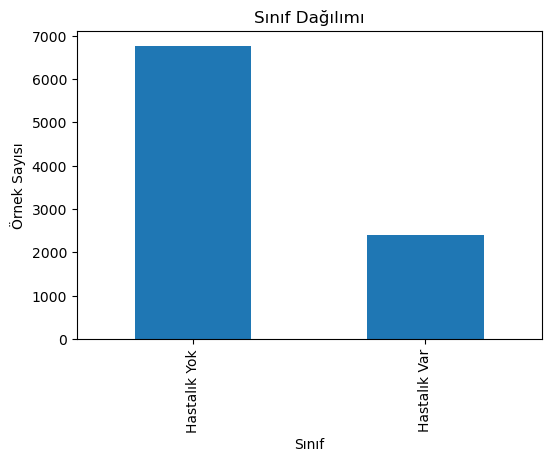

In [21]:
plt.figure(figsize=(6,4))
y.value_counts().rename({
    0: "Hastalık Yok",
    1: "Hastalık Var"
}).plot(kind="bar")

plt.title("Sınıf Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Örnek Sayısı")

plt.show()

In [22]:
class_table = pd.DataFrame({
    "Sınıf": ["Hastalık Yok", "Hastalık Var"],
    "Sayı": y.value_counts().sort_index().values,
    "Oran (%)": (y.value_counts(normalize=True).sort_index() * 100).round(2).values
})

print(class_table)

          Sınıf  Sayı  Oran (%)
0  Hastalık Yok  6771     73.82
1  Hastalık Var  2401     26.18


In [4]:
df[29] = df[29].astype(str).str.replace(r"\[.*\]", "", regex=True)

print(df[29].value_counts())

29
-      6771
K       436
G       359
I       346
F       233
R       196
A       147
L       115
M       111
N       110
S        85
GK       49
AK       46
J        30
B        21
MK       16
Q        14
O        14
C|I      12
KJ       11
GI       10
H|K       8
D         8
FK        6
C         6
P         5
MI        2
LJ        1
GKJ       1
OI        1
D|R       1
E         1
Name: count, dtype: int64


In [5]:
data = df.copy()

data["target"] = data[29].apply(lambda x: 0 if x == "-" else 1)

print(data["target"].value_counts())
print(data["target"].value_counts(normalize=True) * 100)

target
0    6771
1    2401
Name: count, dtype: int64
target
0    73.822503
1    26.177497
Name: proportion, dtype: float64


In [6]:
X = data.drop(columns=[29, "target"])
y = data["target"]

feature_names = [
    "age", "sex", "on_thyroxine", "query_on_thyroxine",
    "on_antithyroid_medication", "sick", "pregnant",
    "thyroid_surgery", "I131_treatment", "query_hypothyroid",
    "query_hyperthyroid", "lithium", "goitre", "tumor",
    "hypopituitary", "psych", "TSH_measured", "TSH",
    "T3_measured", "T3", "TT4_measured", "TT4",
    "T4U_measured", "T4U", "FTI_measured", "FTI",
    "TBG_measured", "TBG", "referral_source"
]

X.columns = feature_names

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
def calculate_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Sensitivity / Recall": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1-score": f1
    }

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1319   36]
 [  32  448]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1355
           1       0.93      0.93      0.93       480

    accuracy                           0.96      1835
   macro avg       0.95      0.95      0.95      1835
weighted avg       0.96      0.96      0.96      1835



In [10]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

[[1324   31]
 [  30  450]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1355
           1       0.94      0.94      0.94       480

    accuracy                           0.97      1835
   macro avg       0.96      0.96      0.96      1835
weighted avg       0.97      0.97      0.97      1835



In [11]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("En iyi parametreler:")
print(grid_search.best_params_)

print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

En iyi parametreler:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
[[1318   37]
 [  29  451]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1355
           1       0.92      0.94      0.93       480

    accuracy                           0.96      1835
   macro avg       0.95      0.96      0.95      1835
weighted avg       0.96      0.96      0.96      1835



In [15]:
results = []
results.append(calculate_metrics(y_test, y_pred, "Random Forest"))
results.append(calculate_metrics(y_test, dt_pred, "Decision Tree"))
results.append(calculate_metrics(y_test, y_pred_tuned, "Tuned Random Forest"))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Sensitivity / Recall,Specificity,Precision,F1-score
0,Random Forest,0.962943,0.933333,0.973432,0.925620,0.929461
1,Decision Tree,0.966757,0.937500,0.977122,0.935551,0.936524
2,Tuned Random Forest,0.964033,0.939583,0.972694,0.924180,0.931818


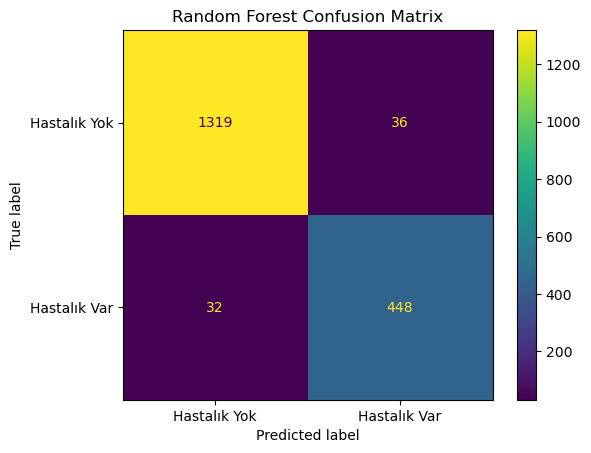

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Hastalık Yok", "Hastalık Var"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

            Feature  Importance
17              TSH    0.254560
19               T3    0.209154
25              FTI    0.162424
21              TT4    0.138329
23              T4U    0.084490
0               age    0.032963
27              TBG    0.030666
28  referral_source    0.021489
18      T3_measured    0.010619
2      on_thyroxine    0.008366


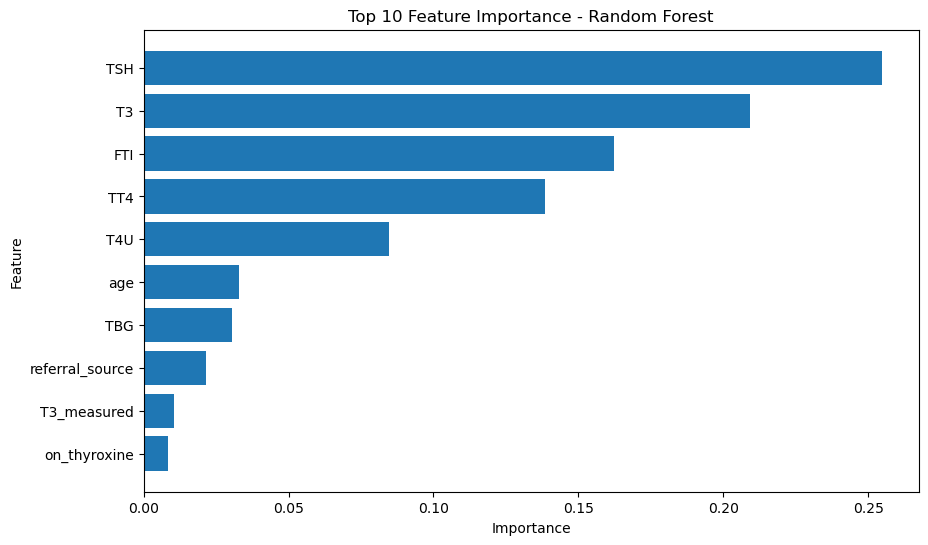

In [17]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"].head(10),
    importance_df["Importance"].head(10)
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.show()